<a href="https://colab.research.google.com/github/xorai30k/College_Statistics/blob/main/StatProb4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [8]:
# ============================================================
# 1. IMPORTS & THEME
# ============================================================
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, HTML

BG, PANEL, GRID, TEXT = "#1a0f1a", "#2b1524", "#4a2540", "#ffe6f2"
ROSE, PINK, MAGENTA, CREAM = "#ff8fb1", "#ff5c8a", "#ff2bd6", "#ffd6e0"

plt.rcParams.update({
    "figure.facecolor": BG, "axes.facecolor": PANEL, "savefig.facecolor": BG,
    "axes.edgecolor": GRID, "axes.labelcolor": TEXT, "axes.titlecolor": TEXT,
    "xtick.color": CREAM, "ytick.color": CREAM, "text.color": TEXT,
    "axes.titleweight": "bold", "axes.titlesize": 13, "axes.labelsize": 11,
    "grid.color": GRID, "grid.linestyle": "--", "grid.alpha": 0.6,
    "font.size": 11,
})

ROSE_COLORS = [ROSE, PINK, MAGENTA, CREAM, "#ffb3c9", "#e75480"]


# --- Pretty HTML helpers ---
def section(title, subtitle=""):
    display(HTML(f"""
    <div style="margin:24px 0 10px 0; padding:12px 18px; border-radius:12px;
                background:linear-gradient(90deg,{BG},{PANEL});
                border-left:4px solid {PINK}; box-shadow:0 0 16px rgba(255,92,138,.25);
                font-family:'Segoe UI',sans-serif;">
        <div style="color:{PINK}; font-size:18px; font-weight:700; letter-spacing:2px;">
            🌹 {title.upper()}</div>
        <div style="color:{CREAM}; font-size:12px; margin-top:2px;">{subtitle}</div>
    </div>"""))


def rose_table(df, caption="", fmt=None, hide_index=False, max_height=None):
    sty = df.style
    if hide_index:
        sty = sty.hide(axis="index")
    if fmt:
        sty = sty.format(fmt)
    sty = sty.set_caption(caption).set_table_styles([
        {"selector": "", "props": [("width", "100%"), ("border-collapse", "separate"),
                                   ("font-family", "'Segoe UI',sans-serif"),
                                   ("font-size", "13px"), ("color", TEXT),
                                   ("background-color", BG)]},
        {"selector": "caption", "props": [("caption-side", "top"), ("text-align", "left"),
                                          ("color", ROSE), ("font-weight", "700"),
                                          ("font-size", "14px"), ("padding", "0 0 8px 4px")]},
        {"selector": "thead th", "props": [("background", f"linear-gradient(90deg,{PINK},{MAGENTA})"),
                                           ("color", "#1a0f1a"), ("text-align", "center"),
                                           ("padding", "10px 14px"), ("font-weight", "700"),
                                           ("text-transform", "uppercase")]},
        {"selector": "tbody td", "props": [("text-align", "center"), ("padding", "8px 14px"),
                                           ("border-bottom", f"1px solid {GRID}")]},
        {"selector": "tbody th", "props": [("text-align", "left"), ("padding", "8px 14px"),
                                           ("color", ROSE), ("font-weight", "600"),
                                           ("background-color", PANEL),
                                           ("border-bottom", f"1px solid {GRID}")]},
        {"selector": "tbody tr:nth-child(even) td", "props": [("background-color", PANEL)]},
        {"selector": "tbody tr:hover td", "props": [("background-color", "rgba(255,92,138,.20)")]},
    ])
    scroll = f"max-height:{max_height}px; overflow-y:auto;" if max_height else ""
    display(HTML(f"""
    <div style="{scroll} border:1px solid {GRID}; border-radius:12px; padding:14px;
                background:{BG}; box-shadow:0 0 20px rgba(255,92,138,.18);">
        {sty.to_html()}
    </div>"""))

In [9]:
# ============================================================
# 2. LOAD DATA
# ============================================================
dataraw = pd.read_excel("DataScore.xlsx")

section("Data Mentah", f"{len(dataraw)} baris • {dataraw.shape[1]} kolom")
rose_table(dataraw, caption="TABEL DATA SCORE", hide_index=True, max_height=420)

Name,Marks in Quiz (Out of 100),Mid Term Results (Out of 100),Final Term Resul (Out of 100),Final Score,Grade
M. Ikhsan Dwi Putra,88,83,78,82.850000,A
Asahina Mafuyu,85,78,90,84.440000,A
Yoisaki Kanade,92,88,94,91.380000,A
Michael Johnson,48,65,56,56.410000,C
Shinonome Ena,90,85,88,87.650000,A
Daniel Martinez,75,80,77,77.350000,AB
Sarah Wilson,88,70,65,74.010000,B
David Garcia,75,70,75,73.350000,B
Akiyama Mizuki,95,91,96,94.030000,A
Matthew Davis,79,84,78,80.300000,AB


Grade,Frekuensi
A,13
AB,7
B,4
BC,1
C,5
F,1


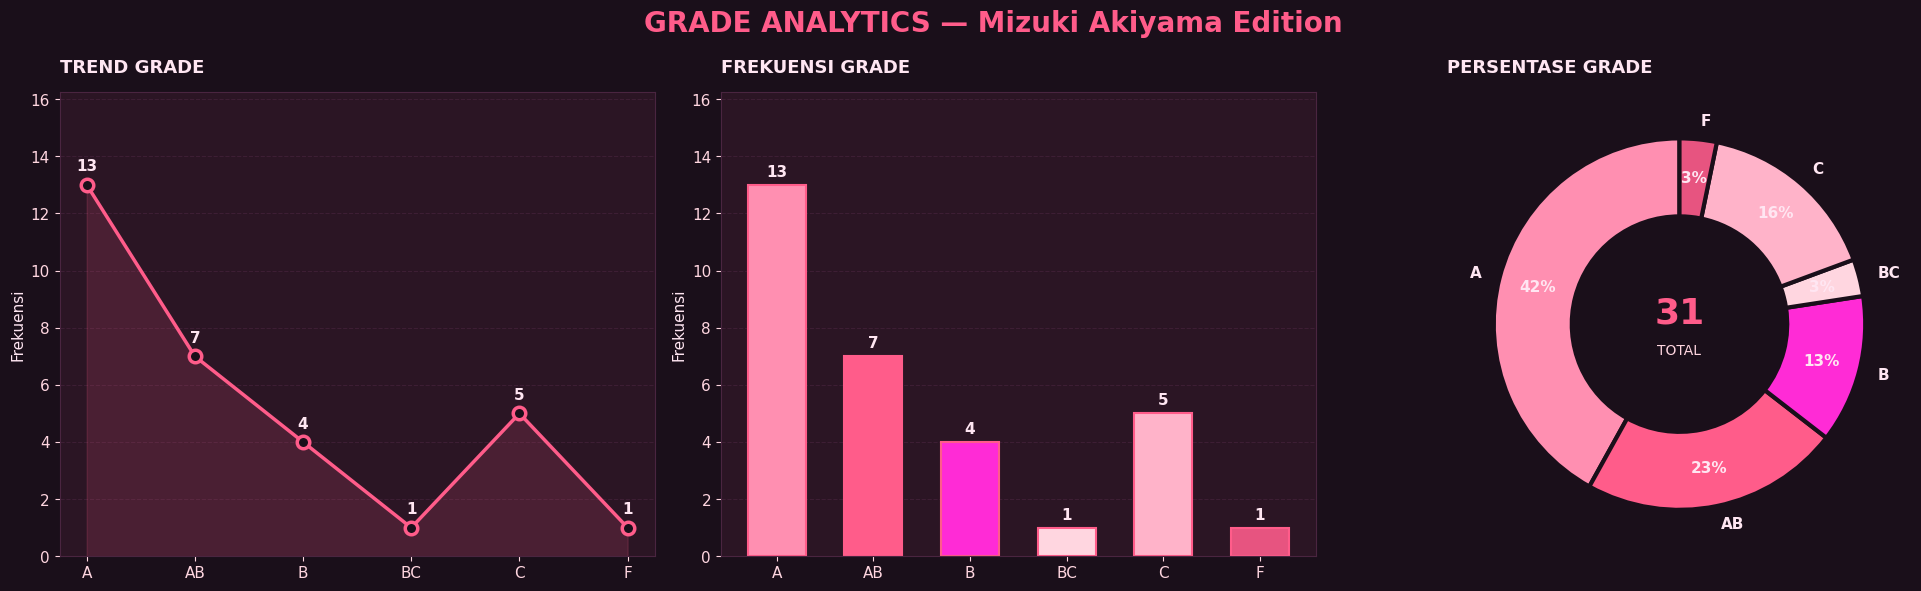

In [15]:
# ============================================================
# 3. FREKUENSI + VISUALISASI
# ============================================================
datafrq = pd.crosstab(index=dataraw["Grade"], columns="Frekuensi")
datafrq.columns.name = None

# Reset index so "Grade" becomes a regular column (fixes header alignment)
datafrq = datafrq.reset_index()

section("Tabel Frekuensi", "Distribusi jumlah data per Grade")
rose_table(datafrq, caption="TABEL FREKUENSI GRADE", hide_index=True)

# --- 3-panel dashboard ---
section("Visualisasi", "Line • Bar • Donut")

# Use the reset dataframe for plotting
labels = datafrq["Grade"].astype(str).tolist()
values = datafrq["Frekuensi"].tolist()
colors = ROSE_COLORS[:len(values)]

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle("GRADE ANALYTICS — Mizuki Akiyama Edition",
             fontsize=20, fontweight="bold", color=PINK)

# Panel 1 — Line
ax = axes[0]
ax.plot(labels, values, color=PINK, lw=2.5, marker="o", ms=9,
        mfc=BG, mec=PINK, mew=2.5)
ax.fill_between(range(len(values)), values, color=PINK, alpha=0.15)
for i, v in enumerate(values):
    ax.annotate(str(v), (i, v), textcoords="offset points",
                xytext=(0, 10), ha="center", fontweight="bold", color=TEXT)
ax.set_ylim(0, max(values) * 1.25)
ax.set_title("TREND GRADE", loc="left", pad=14)
ax.set_ylabel("Frekuensi")
ax.grid(axis="y"); ax.set_axisbelow(True)

# Panel 2 — Bar
ax = axes[1]
bars = ax.bar(labels, values, color=colors, width=0.6,
              edgecolor=PINK, linewidth=1.5)
ax.bar_label(bars, padding=4, color=TEXT, fontweight="bold")
ax.set_ylim(0, max(values) * 1.25)
ax.set_title("FREKUENSI GRADE", loc="left", pad=14)
ax.set_ylabel("Frekuensi")
ax.grid(axis="y"); ax.set_axisbelow(True)

# Panel 3 — Donut
ax = axes[2]
ax.set_facecolor(BG)
ax.pie(values, labels=labels, colors=colors, autopct="%1.0f%%",
       startangle=90, pctdistance=0.79, labeldistance=1.10,
       wedgeprops=dict(width=0.42, edgecolor=BG, linewidth=3),
       textprops=dict(color=TEXT, fontsize=11, fontweight="bold"))
ax.text(0, 0.06, str(sum(values)), ha="center", va="center",
        fontsize=26, fontweight="bold", color=PINK)
ax.text(0, -0.14, "TOTAL", ha="center", va="center",
        fontsize=10, color=CREAM)
ax.set_title("PERSENTASE GRADE", loc="left", pad=14)

plt.tight_layout()
plt.show()

In [16]:
# ============================================================
# 4. STATISTIKA DESKRIPTIF
# ============================================================
dataraw["Final Score"] = pd.to_numeric(dataraw["Final Score"], errors="coerce")
dt = dataraw["Final Score"]

stats = dt.describe()
stats["Standard Error"] = dt.sem()
stats["Median"]   = dt.median()
stats["Mode"]     = dt.mode().iloc[0]
stats["Variance"] = dt.var()
stats["Range"]    = dt.max() - dt.min()
stats["Skewness"] = dt.skew()
stats["Kurtosis"] = dt.kurtosis()

# Build a clean 2-column dataframe instead of relying on the Series index
df_stats = stats.to_frame(name="Nilai").reset_index()
df_stats.columns = ["Indikator Statistik", "Nilai"]

section("Statistika Deskriptif", "Ringkasan kolom Final Score")
rose_table(df_stats, caption="STATISTIKA FINAL SCORE",
           fmt={"Nilai": "{:.2f}"}, hide_index=True)

Indikator Statistik,Nilai
count,31.00
mean,76.44
std,13.29
min,46.01
25%,68.80
50%,79.30
75%,86.79
max,94.03
Standard Error,2.39
Median,79.30
